# Analyze Pinned Memory from data_pipeline_tuning_offline

In [21]:
import wandb
import pandas as pd

# 1. Initialize API and set parameters
api = wandb.Api()
project_path = "as7629-columbia-university/Multimodal-Nanochat"

# Replace these with the actual names of the runs you want to compare
target_run_names = [
    "baseline_online_w4_persistFalse_pinTrue_profileFalse", 
    "baseline_online_w4_persistFalse_pinFalse_profileFalse"
] 

# Define which summary metrics you want to pull down
metrics_to_compare = [
    "warmup_time", 
    "total_hot_time", 
    "total_training_time",
    "avg_hot_mfu", 
    "avg_hot_tok_per_sec"
]

data = []

# 2. Fetch and extract data for each run
for name in target_run_names:
    runs = api.runs(project_path, filters={"display_name": name})
    
    if len(runs) == 0:
        print(f"Warning: No run found with name '{name}'")
        continue
        
    run = runs[0]
    
    # Build a dictionary of the run's metadata
    run_data = {
        "Run Name": run.name,
        "Run ID": run.id,
        "State": run.state
    }
    
    # --- NEW: Extract Configuration Parameters ---
    # We use .get() just like we do with summary metrics to prevent crashes 
    # if the config key is missing in an older run
    run_data["pin_memory"] = run.config.get("pin_memory", None)
    
    # Extract the summary metrics
    for metric in metrics_to_compare:
        run_data[metric] = run.summary.get(metric, None)
        
    data.append(run_data)

# 3. Create a DataFrame for clean visualization
comparison_df = pd.DataFrame(data)

# Print the final comparison table
print("--- Run Comparison ---")
print(comparison_df.to_string(index=False))

--- Run Comparison ---
                                             Run Name   Run ID    State  pin_memory  warmup_time  total_hot_time  total_training_time  avg_hot_mfu  avg_hot_tok_per_sec
 baseline_online_w4_persistFalse_pinTrue_profileFalse 7d9ffgnq finished        True   461.348282      208.096819           669.445101     3.934686          1573.000000
baseline_online_w4_persistFalse_pinFalse_profileFalse dwgpfrv4 finished       False   409.573214      203.883765           613.456979     4.041978          1615.909091


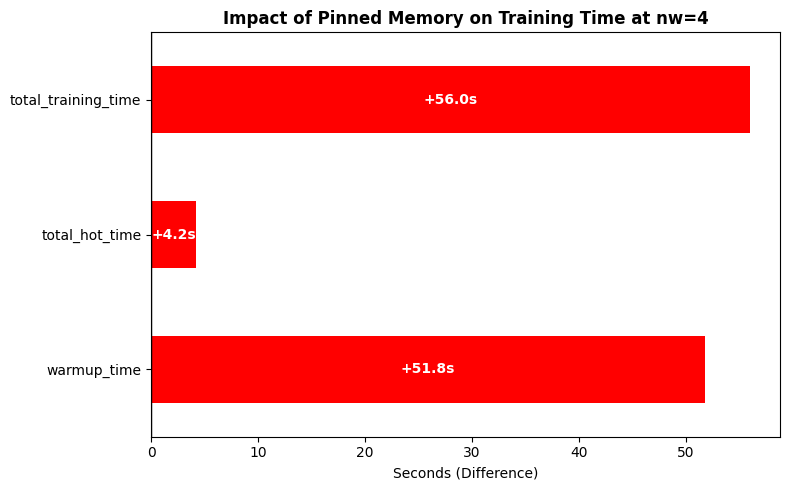

In [15]:
import pandas as pd
import matplotlib.pyplot as plt

# ---------------------------------------------------------
# 1. Recreating your new DataFrame (for testing purposes)
# ---------------------------------------------------------

df = pd.DataFrame(data)

# ---------------------------------------------------------
# 2. Data Preparation using the 'pin_memory' column
# ---------------------------------------------------------
time_cols = ['warmup_time', 'total_hot_time', 'total_training_time']

# Filter the dataframe by the pin_memory flag and extract the time columns as Series
pin_true_times = df[df['pin_memory'] == True][time_cols].iloc[0]
pin_false_times = df[df['pin_memory'] == False][time_cols].iloc[0]

# Calculate the difference (pinTrue - pinFalse)
time_deltas = pin_true_times - pin_false_times

# ---------------------------------------------------------
# 3. Plotting the Diverging Bar Chart
# ---------------------------------------------------------
fig, ax = plt.subplots(figsize=(8, 5))

# Color code: Red for time added (bad), Green for time saved (good)
colors = ['red' if x > 0 else 'green' for x in time_deltas] 

time_deltas.plot(kind='barh', color=colors, ax=ax)
ax.set_title('Impact of Pinned Memory on Training Time at nw=4', fontweight='bold')
ax.set_xlabel('Seconds (Difference)')
ax.axvline(0, color='black', linewidth=1)

# Add text labels centered inside the bars
for i, v in enumerate(time_deltas):
    # Position x in the middle of the bar (v / 2)
    ax.text(v / 2, i, f"{v:+.1f}s", color='white', 
            va='center', ha='center', fontweight='bold')

plt.tight_layout()
plt.show()

# Analyze Num Workers (nw)

In [26]:
import wandb
import pandas as pd

# 1. Initialize API and set parameters
api = wandb.Api()
project_path = "as7629-columbia-university/Multimodal-Nanochat"

# Replace these with the actual names of the runs you want to compare
target_run_names = [
    "baseline_online_w0_persistFalse_pinTrue_profileFalse", 
    "baseline_online_w2_persistFalse_pinTrue_profileFalse",
    "baseline_online_w4_persistFalse_pinTrue_profileFalse"
] 

# Define which summary metrics you want to pull down
metrics_to_compare = [
    "warmup_time", 
    "total_hot_time", 
    "total_training_time",
    "avg_hot_mfu", 
    "avg_hot_tok_per_sec"
]

data = []

# 2. Fetch and extract data for each run
for name in target_run_names:
    runs = api.runs(project_path, filters={"display_name": name})
    
    if len(runs) == 0:
        print(f"Warning: No run found with name '{name}'")
        continue
        
    run = runs[0]
    
    # Build a dictionary of the run's metadata
    run_data = {
        "Run Name": run.name,
        "Run ID": run.id,
        "State": run.state
    }
    
    # --- NEW: Extract Configuration Parameters ---
    # We use .get() just like we do with summary metrics to prevent crashes 
    # if the config key is missing in an older run
    run_data["pin_memory"] = run.config.get("pin_memory", None)
    run_data["num_workers"] = run.config.get("num_workers", None)
    
    # Extract the summary metrics
    for metric in metrics_to_compare:
        run_data[metric] = run.summary.get(metric, None)
        
    data.append(run_data)

# 3. Create a DataFrame for clean visualization
df = pd.DataFrame(data)


# Print the final comparison table
print("--- Run Comparison ---")
print(df.to_string(index=False))

--- Run Comparison ---
                                            Run Name   Run ID    State  pin_memory  num_workers  warmup_time  total_hot_time  total_training_time  avg_hot_mfu  avg_hot_tok_per_sec
baseline_online_w0_persistFalse_pinTrue_profileFalse 1iqksz8s finished        True            0   595.727081      284.050595           879.777676     2.851540          1139.636364
baseline_online_w2_persistFalse_pinTrue_profileFalse mxeabn79 finished        True            2   463.748875      260.759001           724.507876     3.229349          1290.818182
baseline_online_w4_persistFalse_pinTrue_profileFalse 7d9ffgnq finished        True            4   461.348282      208.096819           669.445101     3.934686          1573.000000


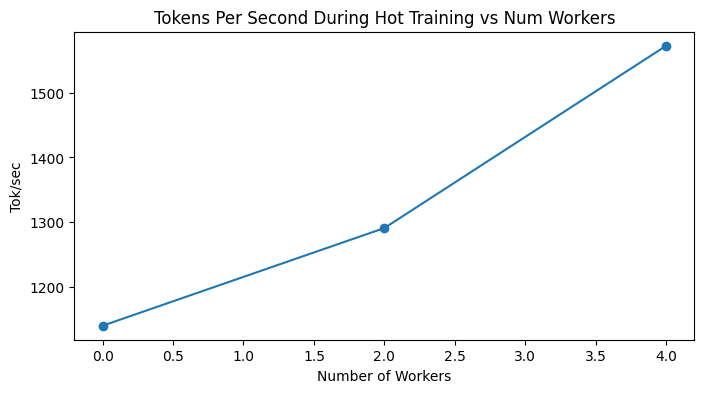

In [49]:
df = df.sort_values('num_workers')

# 1. Line Plot (To see trends/scaling)
plt.figure(figsize=(8, 4))
plt.plot(df['num_workers'], df['avg_hot_tok_per_sec'], marker='o', linestyle='-')
plt.title('Tokens Per Second During Hot Training vs Num Workers')
plt.xlabel('Number of Workers')
plt.ylabel('Tok/sec')
plt.show()

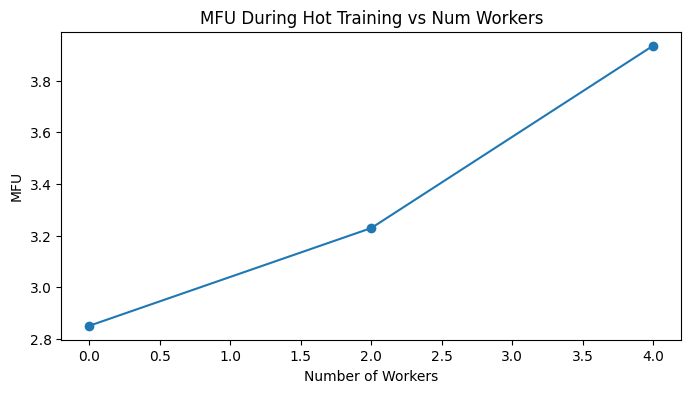

In [50]:
df = df.sort_values('num_workers')

# 1. Line Plot (To see trends/scaling)
plt.figure(figsize=(8, 4))
plt.plot(df['num_workers'], df['avg_hot_mfu'], marker='o', linestyle='-')
plt.title('MFU During Hot Training vs Num Workers')
plt.xlabel('Number of Workers')
plt.ylabel('MFU')
plt.show()

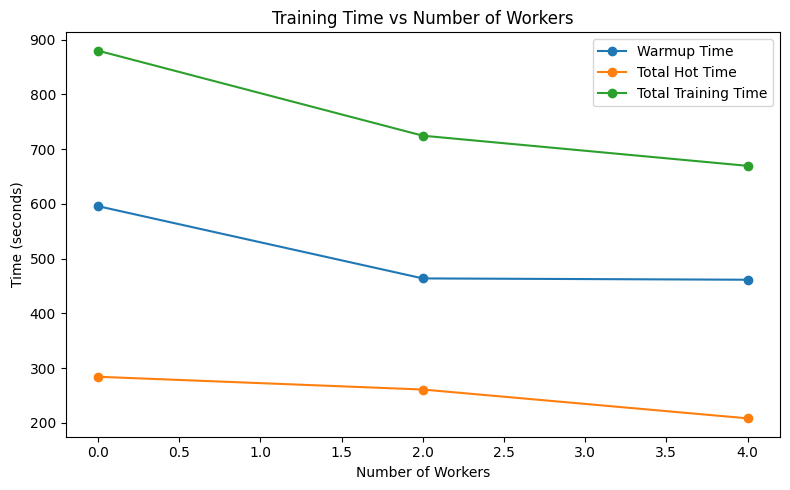

In [52]:
import matplotlib.pyplot as plt

# Assuming your DataFrame 'df' has columns: 'num_workers', 'warmup_time', 'total_hot_time', 'total_training_time'

plt.figure(figsize=(8, 5))

# Plot the three lines
plt.plot(df['num_workers'], df['warmup_time'], marker='o', label='Warmup Time')
plt.plot(df['num_workers'], df['total_hot_time'], marker='o', label='Total Hot Time')
plt.plot(df['num_workers'], df['total_training_time'], marker='o', label='Total Training Time')

# Add labels and legend
plt.title('Training Time vs Number of Workers')
plt.xlabel('Number of Workers')
plt.ylabel('Time (seconds)')
plt.legend()

plt.tight_layout()
plt.show()

# Analyzing Persistent Workers

In [53]:
import wandb
import pandas as pd

# 1. Initialize API and set parameters
api = wandb.Api()
project_path = "as7629-columbia-university/Multimodal-Nanochat"

# Replace these with the actual names of the runs you want to compare
target_run_names = [
    "baseline_online_w4_persistTrue_pinTrue_profileFalse", 
    "baseline_online_w4_persistFalse_pinTrue_profileFalse"
] 

# Define which summary metrics you want to pull down
metrics_to_compare = [
    "warmup_time", 
    "total_hot_time", 
    "total_training_time",
    "avg_hot_mfu", 
    "avg_hot_tok_per_sec"
]

data = []

# 2. Fetch and extract data for each run
for name in target_run_names:
    runs = api.runs(project_path, filters={"display_name": name})
    
    if len(runs) == 0:
        print(f"Warning: No run found with name '{name}'")
        continue
        
    run = runs[0]
    
    # Build a dictionary of the run's metadata
    run_data = {
        "Run Name": run.name,
        "Run ID": run.id,
        "State": run.state
    }
    
    # --- NEW: Extract Configuration Parameters ---
    # We use .get() just like we do with summary metrics to prevent crashes 
    # if the config key is missing in an older run
    run_data["persistent_workers"] = run.config.get("persistent_workers", None)
    
    # Extract the summary metrics
    for metric in metrics_to_compare:
        run_data[metric] = run.summary.get(metric, None)
        
    data.append(run_data)

# 3. Create a DataFrame for clean visualization
comparison_df = pd.DataFrame(data)

# Print the final comparison table
print("--- Run Comparison ---")
print(comparison_df.to_string(index=False))

--- Run Comparison ---
                                            Run Name   Run ID    State  persistent_workers  warmup_time  total_hot_time  total_training_time  avg_hot_mfu  avg_hot_tok_per_sec
 baseline_online_w4_persistTrue_pinTrue_profileFalse g1t0aqvq finished                True   424.078510      214.336245           638.414755     3.795633          1517.363636
baseline_online_w4_persistFalse_pinTrue_profileFalse 7d9ffgnq finished               False   461.348282      208.096819           669.445101     3.934686          1573.000000


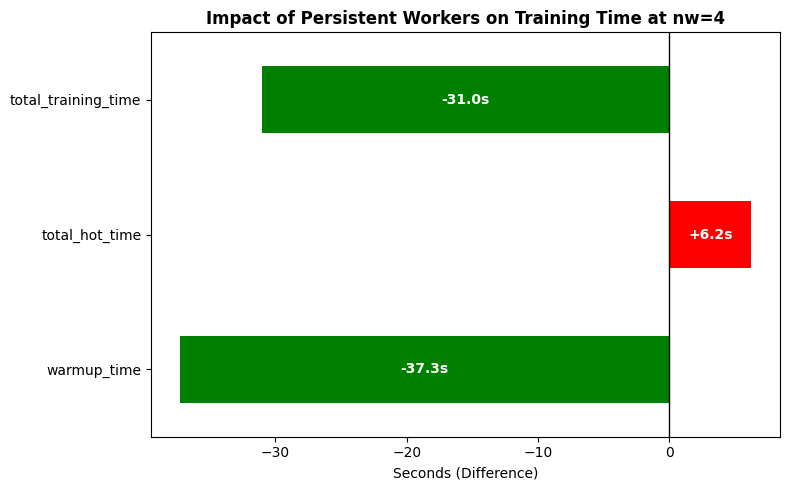

In [56]:
import pandas as pd
import matplotlib.pyplot as plt

# ---------------------------------------------------------
# 1. Recreating your new DataFrame (for testing purposes)
# ---------------------------------------------------------

df = pd.DataFrame(data)

# ---------------------------------------------------------
# 2. Data Preparation using the 'pin_memory' column
# ---------------------------------------------------------
time_cols = ['warmup_time', 'total_hot_time', 'total_training_time']

# Filter the dataframe by the pin_memory flag and extract the time columns as Series
pin_true_times = df[df['persistent_workers'] == True][time_cols].iloc[0]
pin_false_times = df[df['persistent_workers'] == False][time_cols].iloc[0]

# Calculate the difference (pinTrue - pinFalse)
time_deltas = pin_true_times - pin_false_times

# ---------------------------------------------------------
# 3. Plotting the Diverging Bar Chart
# ---------------------------------------------------------
fig, ax = plt.subplots(figsize=(8, 5))

# Color code: Red for time added (bad), Green for time saved (good)
colors = ['red' if x > 0 else 'green' for x in time_deltas] 

time_deltas.plot(kind='barh', color=colors, ax=ax)
ax.set_title('Impact of Persistent Workers on Training Time at nw=4', fontweight='bold')
ax.set_xlabel('Seconds (Difference)')
ax.axvline(0, color='black', linewidth=1)

# Add text labels centered inside the bars
for i, v in enumerate(time_deltas):
    # Position x in the middle of the bar (v / 2)
    ax.text(v / 2, i, f"{v:+.1f}s", color='white', 
            va='center', ha='center', fontweight='bold')

plt.tight_layout()
plt.show()

# Compare offline vs online image embeddings

In [62]:
import wandb
import pandas as pd

# 1. Initialize API and set parameters
api = wandb.Api()
project_path = "as7629-columbia-university/Multimodal-Nanochat"

# Replace these with the actual names of the runs you want to compare
target_run_names = [
    "baseline_online_w4_persistFalse_pinTrue_profileFalse",  # best online setting
    "baseline_offline_pinTrue_profileFalse"
] 

# Define which summary metrics you want to pull down
metrics_to_compare = [
    "warmup_time", 
    "total_hot_time", 
    "total_training_time",
    "avg_hot_mfu", 
    "avg_hot_tok_per_sec"
]

data = []

# 2. Fetch and extract data for each run
for name in target_run_names:
    runs = api.runs(project_path, filters={"display_name": name})
    
    if len(runs) == 0:
        print(f"Warning: No run found with name '{name}'")
        continue
        
    run = runs[0]
    
    # Build a dictionary of the run's metadata
    run_data = {
        "Run Name": run.name,
        "Run ID": run.id,
        "State": run.state
    }
    
    # --- NEW: Extract Configuration Parameters ---
    # We use .get() just like we do with summary metrics to prevent crashes 
    # if the config key is missing in an older run
    run_data["compute_embeddings"] = run.config.get("compute_embeddings", None)
    
    # Extract the summary metrics
    for metric in metrics_to_compare:
        run_data[metric] = run.summary.get(metric, None)
        
    data.append(run_data)

# 3. Create a DataFrame for clean visualization
df = pd.DataFrame(data)

# Print the final comparison table
print("--- Run Comparison ---")
print(comparison_df.to_string(index=False))

--- Run Comparison ---
                                            Run Name   Run ID    State  compute_embeddings  warmup_time  total_hot_time  total_training_time  avg_hot_mfu  avg_hot_tok_per_sec
baseline_online_w4_persistFalse_pinTrue_profileFalse 7d9ffgnq finished                True   461.348282      208.096819           669.445101     3.934686          1573.000000
               baseline_offline_pinTrue_profileFalse hx9jqg2u finished               False    65.623419       33.024591            98.648010    24.799295          9916.545455


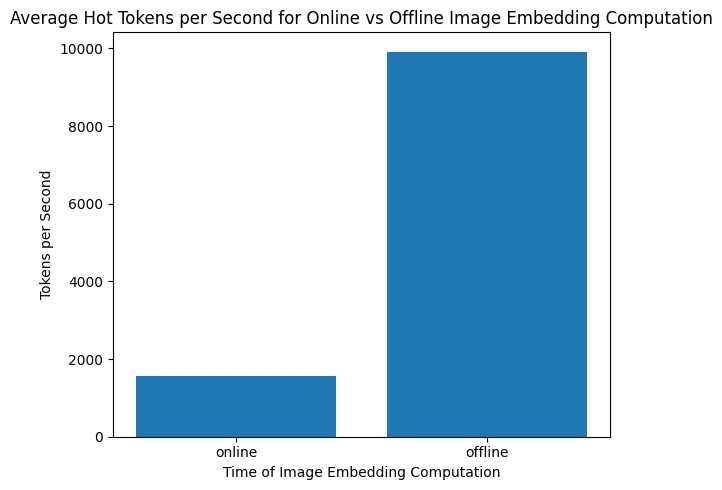

In [67]:
# 1. Extract values for MFU based on the compute_embeddings flag
compute_embeddings_true_mfu = df[df['compute_embeddings'] == True]['avg_hot_tok_per_sec'].iloc[0]
compute_embeddings_false_mfu = df[df['compute_embeddings'] == False]['avg_hot_tok_per_sec'].iloc[0]

# 2. Create simple lists for the x-axis and y-axis
labels = ['online', 'offline']
mfu_values = [compute_embeddings_true_mfu, compute_embeddings_false_mfu]

# 3. Create the single plot
plt.figure(figsize=(6, 5))
plt.bar(labels, mfu_values)

# 4. Add labels and limits
plt.title('Average Hot Tokens per Second for Online vs Offline Image Embedding Computation')
plt.ylabel('Tokens per Second')
plt.xlabel("Time of Image Embedding Computation")

plt.tight_layout()
plt.show()

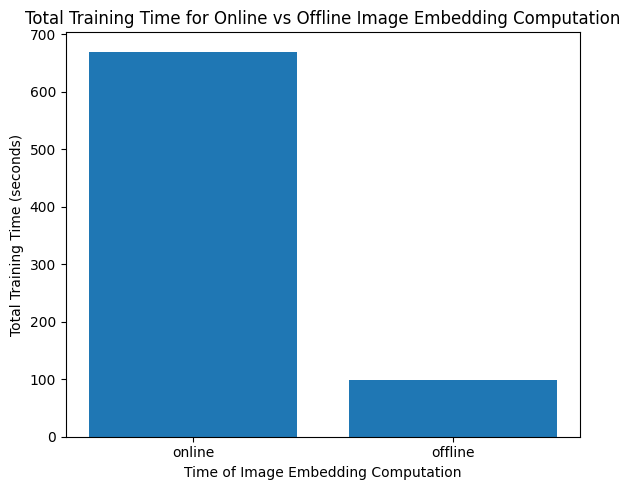

In [70]:
# 1. Extract values for MFU based on the compute_embeddings flag
compute_embeddings_true_mfu = df[df['compute_embeddings'] == True]['total_training_time'].iloc[0]
compute_embeddings_false_mfu = df[df['compute_embeddings'] == False]['total_training_time'].iloc[0]

# 2. Create simple lists for the x-axis and y-axis
labels = ['online', 'offline']
mfu_values = [compute_embeddings_true_mfu, compute_embeddings_false_mfu]

# 3. Create the single plot
plt.figure(figsize=(6, 5))
plt.bar(labels, mfu_values)

# 4. Add labels and limits
plt.title('Total Training Time for Online vs Offline Image Embedding Computation')
plt.ylabel('Total Training Time (seconds)')
plt.xlabel("Time of Image Embedding Computation")

plt.tight_layout()
plt.show()

In [74]:
import wandb
import pandas as pd

# 1. Initialize API and set parameters
api = wandb.Api()
project_path = "as7629-columbia-university/Multimodal-Nanochat"

# Replace these with the actual names of the runs you want to compare
target_run_names = [
    "baseline_offline_pinFalse_profileFalse", 
    "baseline_offline_pinTrue_profileFalse"
] 

# Define which summary metrics you want to pull down
metrics_to_compare = [
    "warmup_time", 
    "total_hot_time", 
    "total_training_time",
    "avg_hot_tok_per_sec"
]

data = []

# 2. Fetch and extract data for each run
for name in target_run_names:
    runs = api.runs(project_path, filters={"display_name": name})
    
    if len(runs) == 0:
        print(f"Warning: No run found with name '{name}'")
        continue
        
    run = runs[0]
    
    # Build a dictionary of the run's metadata
    run_data = {
        "Run Name": run.name,
        "Run ID": run.id,
        "State": run.state
    }
    
    # --- NEW: Extract Configuration Parameters ---
    # We use .get() just like we do with summary metrics to prevent crashes 
    # if the config key is missing in an older run
    run_data["pin_memory"] = run.config.get("pin_memory", None)
    
    # Extract the summary metrics
    for metric in metrics_to_compare:
        run_data[metric] = run.summary.get(metric, None)
        
    data.append(run_data)

# 3. Create a DataFrame for clean visualization
comparison_df = pd.DataFrame(data)
df = comparison_df
# Print the final comparison table
print("--- Run Comparison ---")
print(comparison_df.to_string(index=False))

--- Run Comparison ---
                              Run Name   Run ID    State  pin_memory  warmup_time  total_hot_time  total_training_time  avg_hot_tok_per_sec
baseline_offline_pinFalse_profileFalse tzqkgfas finished       False    66.006925       33.214717            99.221642          9858.909091
 baseline_offline_pinTrue_profileFalse hx9jqg2u finished        True    65.623419       33.024591            98.648010          9916.545455


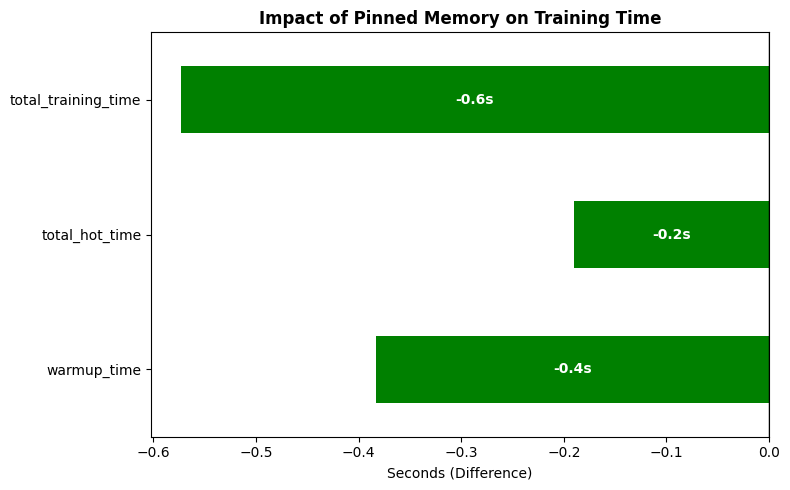

In [76]:
df = pd.DataFrame(data)

# ---------------------------------------------------------
# 2. Data Preparation using the 'pin_memory' column
# ---------------------------------------------------------
time_cols = ['warmup_time', 'total_hot_time', 'total_training_time']

# Filter the dataframe by the pin_memory flag and extract the time columns as Series
pin_true_times = df[df['pin_memory'] == True][time_cols].iloc[0]
pin_false_times = df[df['pin_memory'] == False][time_cols].iloc[0]

# Calculate the difference (pinTrue - pinFalse)
time_deltas = pin_true_times - pin_false_times

# ---------------------------------------------------------
# 3. Plotting the Diverging Bar Chart
# ---------------------------------------------------------
fig, ax = plt.subplots(figsize=(8, 5))

# Color code: Red for time added (bad), Green for time saved (good)
colors = ['red' if x > 0 else 'green' for x in time_deltas] 

time_deltas.plot(kind='barh', color=colors, ax=ax)
ax.set_title('Impact of Pinned Memory on Training Time', fontweight='bold')
ax.set_xlabel('Seconds (Difference)')
ax.axvline(0, color='black', linewidth=1)

# Add text labels centered inside the bars
for i, v in enumerate(time_deltas):
    # Position x in the middle of the bar (v / 2)
    ax.text(v / 2, i, f"{v:+.1f}s", color='white', 
            va='center', ha='center', fontweight='bold')

plt.tight_layout()
plt.show()

# AMP

In [ ]:
import wandb
import pandas as pd

# 1. Initialize API and set parameters
api = wandb.Api()
project_path = "as7629-columbia-university/Multimodal-Nanochat"

# Replace these with the actual names of the runs you want to compare
target_run_names = [
    "baseline_online_w4_persistFalse_pinTrue_profileFalse", 
    "baseline_online_w4_persistFalse_pinFalse_profileFalse"
] 

# Define which summary metrics you want to pull down
metrics_to_compare = [
    "warmup_time", 
    "total_hot_time", 
    "total_training_time",
    "avg_hot_mfu", 
    "avg_hot_tok_per_sec"
]

data = []

# 2. Fetch and extract data for each run
for name in target_run_names:
    runs = api.runs(project_path, filters={"display_name": name})
    
    if len(runs) == 0:
        print(f"Warning: No run found with name '{name}'")
        continue
        
    run = runs[0]
    
    # Build a dictionary of the run's metadata
    run_data = {
        "Run Name": run.name,
        "Run ID": run.id,
        "State": run.state
    }
    
    # --- NEW: Extract Configuration Parameters ---
    # We use .get() just like we do with summary metrics to prevent crashes 
    # if the config key is missing in an older run
    run_data["pin_memory"] = run.config.get("pin_memory", None)
    
    # Extract the summary metrics
    for metric in metrics_to_compare:
        run_data[metric] = run.summary.get(metric, None)
        
    data.append(run_data)

# 3. Create a DataFrame for clean visualization
comparison_df = pd.DataFrame(data)

# Print the final comparison table
print("--- Run Comparison ---")
print(comparison_df.to_string(index=False))

# Presentation Plots

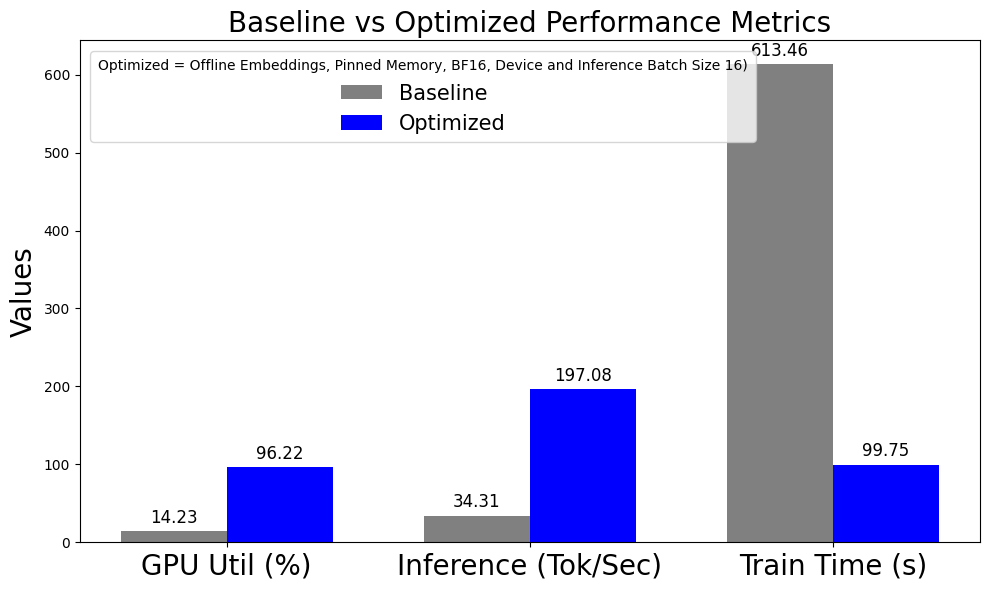

In [18]:
import matplotlib.pyplot as plt
import numpy as np

# Data
labels = ['GPU Util (%)', 'Inference (Tok/Sec)', 'Train Time (s)']
baseline = [14.23, 34.30844, 613.45698]
optimized = [96.22, 197.0843, 99.74508]

# Set up the bar locations and width
x = np.arange(len(labels))
width = 0.35

fig, ax = plt.subplots(figsize=(10, 6))

# Plot the bars
rects1 = ax.bar(x - width/2, baseline, width, label='Baseline', color='grey')
rects2 = ax.bar(x + width/2, optimized, width, label='Optimized', color='blue')

# Formatting and labels
ax.set_ylabel('Values', size=20)
ax.set_title('Baseline vs Optimized Performance Metrics', size=20)
ax.set_xticks(x)
ax.set_xticklabels(labels, size=20)
ax.legend(title="Optimized = Offline Embeddings, Pinned Memory, BF16, Device and Inference Batch Size 16)", fontsize=15, loc='upper left')

# Add text labels on top of the bars, rounded to 2 decimal places
ax.bar_label(rects1, padding=3, fmt='%.2f', size=12)
ax.bar_label(rects2, padding=3, fmt='%.2f', size=12)

fig.tight_layout()

# Save the figure
plt.savefig('performance_comparison.png')

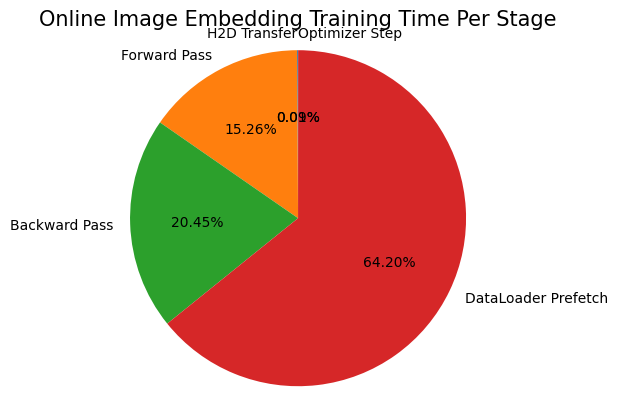

In [ ]:
# from run baseline_online_w4_persistFalse_pinTrue_profileTrue
import matplotlib.pyplot as plt

# 1. Define your data
labels = ['H2D Transfer', 'Forward Pass', 'Backward Pass', 'DataLoader Prefetch', "Optimizer Step"]
sizes = [18.581 , 3095.662 , 4148.218 , 13024.378, 1.083] # These represent the values or percentages for each slice

# 2. Create the pie chart
fig, ax = plt.subplots()
ax.pie(
    sizes, 
    labels=labels, 
    autopct='%1.2f%%', # Automatically formats the values as percentages
    startangle=90      # Rotates the start of the pie chart by 90 degrees
)

# 3. Ensure the pie chart is drawn as a perfect circle
ax.axis('equal')  

# 4. Display or save the chart
plt.title("Online Image Embedding Training Time Per Stage", size=15)
plt.show() 
# Or save it to a file using: plt.savefig('my_pie_chart.png')

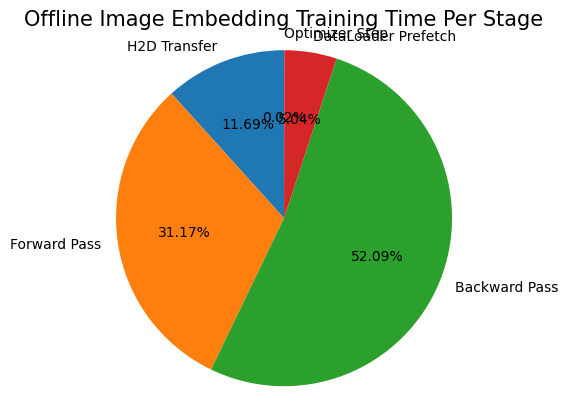

In [ ]:
# from run baseline_offline_pinTrue_profileTrue
# 1. Define your data
labels = ['H2D Transfer', 'Forward Pass', 'Backward Pass', 'DataLoader Prefetch', "Optimizer Step"]
sizes = [396.269  , 1056.882 , 1766.371  , 170.897 , 0.685] # These represent the values or percentages for each slice

# 2. Create the pie chart
fig, ax = plt.subplots()
ax.pie(
    sizes, 
    labels=labels, 
    autopct='%1.2f%%', # Automatically formats the values as percentages
    startangle=90      # Rotates the start of the pie chart by 90 degrees
)

# 3. Ensure the pie chart is drawn as a perfect circle
ax.axis('equal')  

# 4. Display or save the chart
plt.title("Offline Image Embedding Training Time Per Stage", size=15)
plt.show() 
# Or save it to a file using: plt.savefig('my_pie_chart.png')

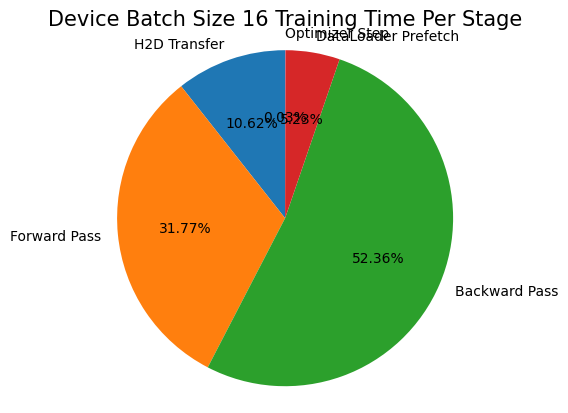

In [8]:
# from run baseline_deviceBS16_bfloat16_profileFalse
# 1. Define your data
labels = ['H2D Transfer', 'Forward Pass', 'Backward Pass', 'DataLoader Prefetch', "Optimizer Step"]
sizes = [358.553  , 1072.616  , 1767.721   , 176.555  , 0.870 ] # These represent the values or percentages for each slice

# 2. Create the pie chart
fig, ax = plt.subplots()
ax.pie(
    sizes, 
    labels=labels, 
    autopct='%1.2f%%', # Automatically formats the values as percentages
    startangle=90      # Rotates the start of the pie chart by 90 degrees
)

# 3. Ensure the pie chart is drawn as a perfect circle
ax.axis('equal')  

# 4. Display or save the chart
# plt.title("BF16 Training Time Per Stage", size=15)
plt.title("Device Batch Size 16 Training Time Per Stage", size=15)

plt.show() 
# Or save it to a file using: plt.savefig('my_pie_chart.png')

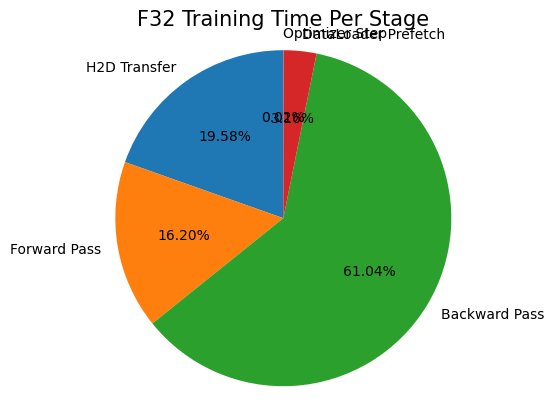

In [96]:
# from run baseline_deviceBS16_bfloat16_profileFalse
# 1. Define your data
labels = ['H2D Transfer', 'Forward Pass', 'Backward Pass', 'DataLoader Prefetch', "Optimizer Step"]
sizes = [982.020   , 812.558   , 3061.317    , 158.476  , 0.842 ] # These represent the values or percentages for each slice

# 2. Create the pie chart
fig, ax = plt.subplots()
ax.pie(
    sizes, 
    labels=labels, 
    autopct='%1.2f%%', # Automatically formats the values as percentages
    startangle=90      # Rotates the start of the pie chart by 90 degrees
)

# 3. Ensure the pie chart is drawn as a perfect circle
ax.axis('equal')  

# 4. Display or save the chart
plt.title("F32 Training Time Per Stage", size=15)
plt.show() 
# Or save it to a file using: plt.savefig('my_pie_chart.png')

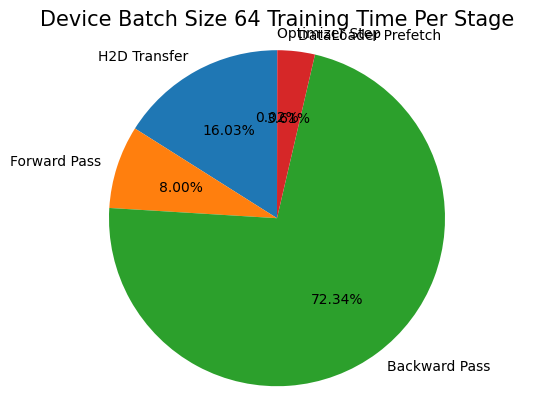

In [9]:
# from run baseline_deviceBS16_bfloat16_profileFalse
# 1. Define your data
labels = ['H2D Transfer', 'Forward Pass', 'Backward Pass', 'DataLoader Prefetch', "Optimizer Step"]
sizes = [662.824   , 330.566   , 2990.558    , 149.341  , 0.792 ] # These represent the values or percentages for each slice

# 2. Create the pie chart
fig, ax = plt.subplots()
ax.pie(
    sizes, 
    labels=labels, 
    autopct='%1.2f%%', # Automatically formats the values as percentages
    startangle=90      # Rotates the start of the pie chart by 90 degrees
)

# 3. Ensure the pie chart is drawn as a perfect circle
ax.axis('equal')  

# 4. Display or save the chart
plt.title("Device Batch Size 64 Training Time Per Stage", size=15)
plt.show() 
# Or save it to a file using: plt.savefig('my_pie_chart.png')

# Tuning Learning Rate

In [1]:
import wandb
import pandas as pd

# 1. Initialize API and set parameters
api = wandb.Api()
project_path = "as7629-columbia-university/Multimodal-Nanochat"

# Replace these with the actual names of the runs you want to compare
target_run_names = [
    "totalBS32768_lr1e-1", 
    "totalBS32768_lr1e-2",
    "totalBS32768_lr1e-3",
    "totalBS32768_lr1e-4"
] 

# Define which summary metrics you want to pull down
metrics_to_compare = [
    "val/bpb",
    "val/avg_semantic_similarity",
    "train/loss"
]

data = []

# 2. Fetch and extract data for each run
for name in target_run_names:
    runs = api.runs(project_path, filters={"display_name": name})
    
    if len(runs) == 0:
        print(f"Warning: No run found with name '{name}'")
        continue
        
    run = runs[0]
    
    # Build a dictionary of the run's metadata
    run_data = {
        "Run Name": run.name,
        "Run ID": run.id,
        "State": run.state
    }
    
    # --- NEW: Extract Configuration Parameters ---
    # We use .get() just like we do with summary metrics to prevent crashes 
    # if the config key is missing in an older run
    run_data["vision_lr"] = run.config.get("vision_lr", None)
    
    # Extract the summary metrics
    for metric in metrics_to_compare:
        run_data[metric] = run.summary.get(metric, None)
        
    data.append(run_data)

# 3. Create a DataFrame for clean visualization
df = pd.DataFrame(data)


# Print the final comparison table
print("--- Run Comparison ---")
print(df.to_string(index=False))

wandb: [wandb.Api()] Loaded credentials for https://api.wandb.ai from /home/as7629/.netrc.


--- Run Comparison ---
           Run Name   Run ID    State  vision_lr  val/bpb  val/avg_semantic_similarity  train/loss
totalBS32768_lr1e-1 09h81lqy finished     0.1000 0.989723                     0.348698    2.760623
totalBS32768_lr1e-2 p79t3b33 finished     0.0100 0.969988                     0.417193    2.669118
totalBS32768_lr1e-3 tywdecvd finished     0.0010 0.959937                     0.384584    2.669711
totalBS32768_lr1e-4 a3sr2x9e finished     0.0001 1.016932                     0.300134    2.874715


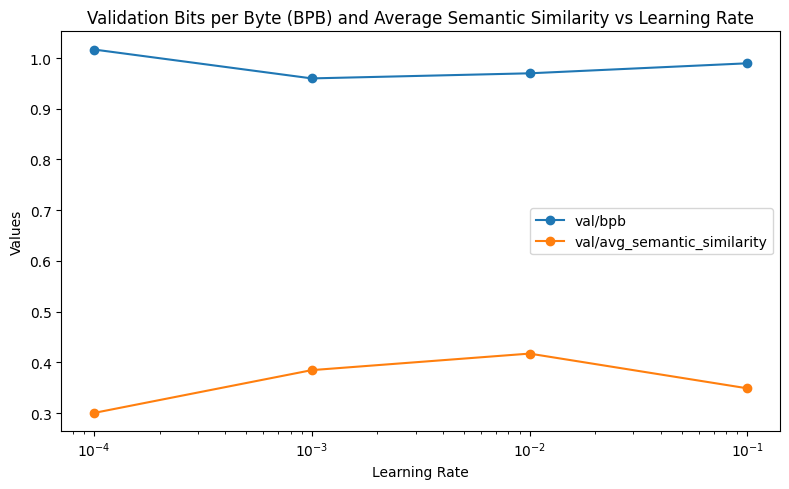

In [5]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))

# Plot the three lines
plt.plot(df['vision_lr'], df['val/bpb'], marker='o', label='val/bpb')
plt.plot(df['vision_lr'], df['val/avg_semantic_similarity'], marker='o', label='val/avg_semantic_similarity')
# plt.plot(df['vision_lr'], df['train/loss'], marker='o', label='train/loss')

# Add labels and legend
plt.title('Validation Bits per Byte (BPB) and Average Semantic Similarity vs Learning Rate')
plt.xlabel('Learning Rate')
plt.xscale('log')
plt.ylabel('Values')
plt.legend()

plt.tight_layout()
plt.show()